![](https://www.dii.uchile.cl/wp-content/uploads/2021/06/Magi%CC%81ster-en-Ciencia-de-Datos.png)

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

### 👨‍🏫👩‍🏫 Cuerpo Docente:

- Profesor: Pablo Badilla, Diego Cortez
- Auxiliar: Melanie Peña Torres, Valentina Rojas Osorio
- Ayudante: Javiera Arévalo, Tamara Carrasco, Ignacio Reyes

### 👨‍💻👩‍💻 Estudiantes:
- Estudiante n°1: Bryan Cabezas 
- Estudiante n°2: Gonzalo Sobarzo

_Por favor, lean detalladamente las instrucciones de la tarea antes de empezar a escribir._

---

## Reglas

El proyecto consta de 3 partes: **Informe de Análisis**, **Construcción del Modelo** y **Despliegue del Modelo**. Este notebook corresponde a la **Parte 3 - Despliegue del Modelo**, y asume que ya completaste la **Parte 2 - Construcción del Modelo**.

### **Requisitos del proyecto**
- **Grupos**: Formar equipos de **2 personas**.
- **Plazo de entrega**: Hasta el Viernes 10 de Julio
- **Consultas**: Cualquier duda fuera del horario de clases debe ser planteada en el foro correspondiente. Los mensajes enviados al equipo docente serán respondidos únicamente por este medio. Por favor, revisen las respuestas anteriores en el foro antes de realizar nuevas consultas.
- **Plagio**: La copia o reutilización no autorizada de trabajos de otros grupos está **estrictamente prohibida**. El incumplimiento de esta norma implicará la anulación inmediata del proyecto y una posible sanción académica.
- **Material permitido**: Pueden usar cualquier material del curso, ya sea notas, lecturas, códigos, o referencias proporcionadas por los docentes, que consideren útil para el desarrollo del proyecto.

---

## 📊 Distribución de Puntaje

La nota va de **1.0 a 7.0** (escala chilena): **1.0 de base + 6.0 puntos** repartidos como se muestra. Se evalúa **el código, lo que implementas y la evidencia que adjuntas**.

| Sección | Qué se evalúa | Puntaje |
|---|---|---:|
| **1 — Adaptación pipeline** | Código y evidencia de función que ejecuta modelo | 1.5 |
| **2 — Despliegue de API** | Código y evidencia de app de FastApi| 1.5 |
| **3 — Despliegue de Frontend** | Código y evidencia de gradio | 1.0 |
| **4 — Contenerización** | Estructura y contenido de archivos, y video de funcionalidad de contenedores | 2.0 |
| | **Total puntos** | **6.0** |
| | **+ Base** | **1.0** |
| | **Nota máxima** | **7.0** |

Esta nota corresponde a la nota de la **Parte 3** que equivale a un **30%** de la nota del proyecto final. Para obtener la nota final, las notas individuales de cada parte se ponderan de la siguiente manera.

| Parte              | Ponderación |
|--------------------|------------:|
| 1 — Análisis       | 30%         |
| 2 — Modelo         | 40%         |
| **3 — Despliegue** | **30%**     |

## 📖 Introducción

<p align="center">
    <img src="./chaucherapp.jpg" alt="Alt Text" width="700">
</p>

La app chilena **ChaucherApp** ha emergido recientemente como una de las nuevas apps *FinTech* que apuesta por dominar en un competitivo mercado. Esta app ofrece una billetera digital que permite hacer transferencias, tarjetas digitales que permiten comprar, y servicios financieros como préstamos, seguros e inversiones.

Sin duda es sorprendente que **ChaucherApp** sea uno de los líderes de la industria fintech, siendo una empresa tan joven. En las palabras del CEO de la empresa, el Sr. Querty _'El gran éxito de ChaucherApp se debe a que entendimos la importancia de escuchar y responder eficientemente al cliente'_. En efecto, **ChaucherApp** fue diseñada desde el comienzo con una robusta arquitectura digital relacionada al **Soporte al cliente**.

Durante años, **ChaucherApp** ha logrado dar respuesta satisfactoria a cientos de tickets de soporte al cliente al mes, lo que le ha permitido inspirar confianza y prestigio. Por supuesto, esto también ha generado una gran cantidad de datos que pueden ser útiles para las siguientes etapas de crecimiento de la empresa. Y es que, a medida que el mercado se hace más competitivo, se hace más necesario aumentar la eficiencia de los procesos de respuesta de tickets, por lo que el Sr. Querty ha optado por **automatizar el proceso** incorporando inteligencia artificial.

Luego de intensa planificación ejecutiva y jornadas de analítica, han decidido que el primer paso para automatizar será el de desarrollar un modelo de **priorización de tickets** de soporte al cliente utilizando **modelos de lenguaje** y **aprendizaje de máquinas**. De esta manera podrán optimizar recursos humanos mientras se desarrollan otras herramientas.

Para lograr esta tarea, te han encargado analizar datos históricos de tickets de soporte al cliente que ya han sido manualmente priorizados, presentes en el archivo `data/tickets.parquet`. En él, encontrarás tickets con el contenido del ticket, categoría, canal, fecha y priorización, que puede ser `Baja`, `Media`, `Alta` o `Crítica`. Tu objetivo es utilizar esa data y los medios, algoritmos y estrategias que estimes convenientes para construir un **modelo clasificador** que sea capaz de predecir esta categoría en base al texto y atributos del ticket.

Con esta información, tus tareas a realizar son primero **analizar y entender los datos**, luego **construir un modelo de inferencia**, y finalmente **implementar ese modelo** para que el equipo de ejecutivos de ChaucherApp pueda utilizarlo.

---

# Parte 3 - Despliegue del Modelo

En la Parte 2 llegaste a la construcción y selección de un modelo final de **clasificación multiclase** que permite predecir predecir el `Nivel_Prioridad` de tickets de soporte al cliente, las cuales pueden ser `Baja`, `Media`, `Alta` y `Crítica`.

Ahora deberás construir una aplicación que permita realizar esta clasificación en tiempo real, de forma que pueda ser utilizada por un hipotético equipo de soporte al cliente. Esta aplicación debe permitir clasificar datos en base a las mismas variables que utilizaste para entrenar el modelo, incluyendo las de **texto**. La app a construir debe poder clasificar cualquier valor nuevo, por lo que admite **cualquier tipo de texto**. Es por esto, que necesita poder consumir un servicio de embeddings para poder vectorizar cualquier texto nuevo, lo cual puede lograr utilizando la api gratuita proporcionada por **Google AI Studio**.

Es importante notar que para que su clasificador funcione correctamente, el modelo y dimensión utilizadas deben ser **exactamente los mismos** que los utilizados en el entrenamiento del modelo

**En esta sección, el código debe quedar en scripts .py**

## Sección 1 - Adaptación pipeline (1.5 pts)

Construya una función que dados los mínimos campos necesarios construya el input del pipeline entrenado anteriormente y luego utilice el pipeline para obtener la categoría.
- Guarde el pipeline completo en un archivo .pickle
- Cree la función ``generate_prediction`` que tome la menor cantidad de parámetros necesarios requeridos y retorne la predicción. Esta función deberá:
  - Vectorizar el texto de forma idéntica a como se construyeron los embeddings que le fueron dados. Para esto: 
    - Concatene el asunto y descripción de esta forma: `Asunto_Ticket: {asunto}\nContenido_Ticket: {contenido}\n`
    - Utilice la clase `GoogleGenerativeAIEmbeddings` de langchain con el modelo `gemini-embedding-001` y la opción `output_dimensionality=1024` para vectorizar el texto de forma análoga a lo que le fue entregado.
  - Procesar el resto de features hasta obtener las mismas variables que usó para la construcción del modelo
  - Cargar el pipeline desde el .pickle y utilizarlo para generar una predicción en base a estas variables
  - Retornar la predicción
- Guarde todo este código en un archivo ``backend/generate_prediction.py``
- Incluya una sección al final de este script que ejecute la función con datos de muestra cuando el script se ejecuta directamente (no a través de una importación)

Finalmente, incluya un screenshot o un link a un screenshot con el output

**⚠️Cuidado: para que funcione deberá incluir su GOOGLE_API_KEY en un archivo de configuración como un .env. RECUERDE NO AGREGAR ESE ARCHIVO AL REPOSITORIO**

**⚠️Se revisará que su código refleje 100% el modelo entrenado. Si es necesario, explore los datos para deducir como algunos atributos fueron construidos (como N_Caracteres_Ticket)**

**Responde aquí**


Dado el código entregado de la sección 4, se escogío automáticamente el modelo MLPClassifier.



Data sintetica:

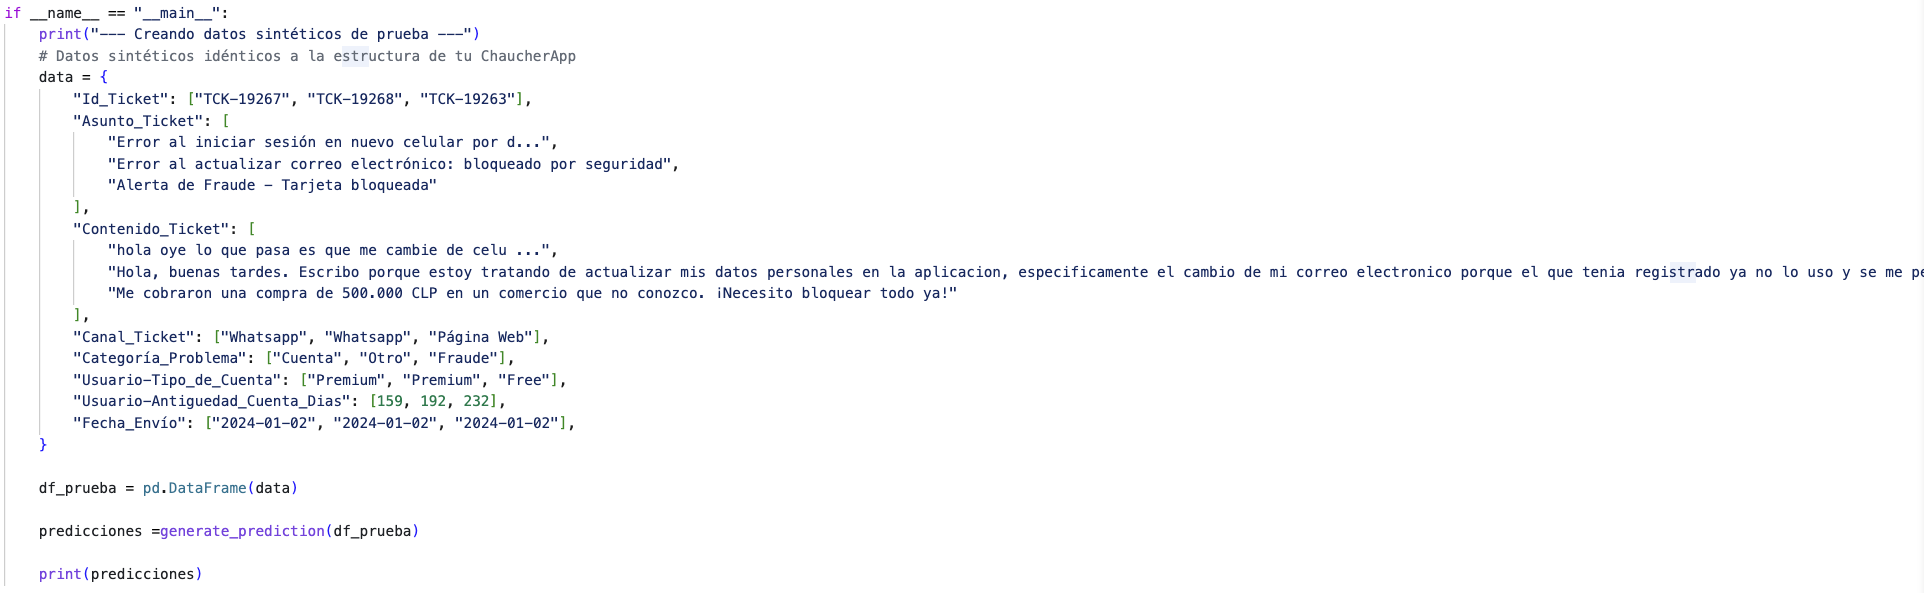

Resultado del modelo:

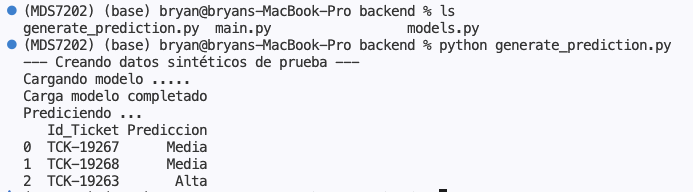





## Sección 2 - Despliegue de API (1.5 pts)

Construya la app de FastApi que habilite un endpoint para realizar la predicción.

- Cree el archivo `backend/main.py` donde definirá sus endpoints. Importe la función `generate_prediction`
- Cree el archivo `backend/models.py`. Defina en él los modelos de `pydantic` para la request (`PredictionRequest`) y response (`PredictionResponse`). Su endpoint debe tener tipado **estricto** y arrojar error 422 (gestionado por fastapi) cuando los argumentos de la request no cumplan con el tipo esperado.
- Cree un endpoint de tipo **POST** con la ruta `/predict` que reciba un payload del tipo `PredictionRequest` y que llame a la función `generate_prediction`, retornando la predicción en un objeto `PredictionResponse`.
- Agregue clausulas de `try/except` que envuelvan la llamada a `generate_prediction` y lance una `HttpException` en caso de error.
- Levante su app de fastapi usando `uvicorn`
- Llame a su app de fastapi usando postman o requests. Incluya una screenshot del input y output de una llamada exitosa, y el input y output de una llamada no exitosa.

**Responde aquí**

Llamada exitosa:

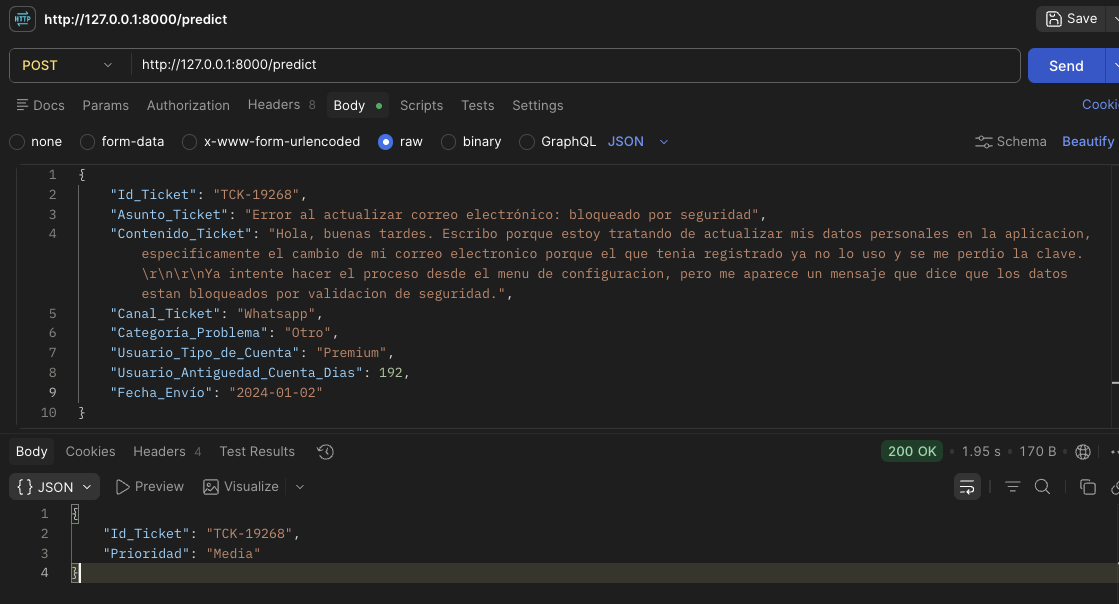

Llamada no exitosa por error de tipeo: Cambio de Id_Ticket por Id:

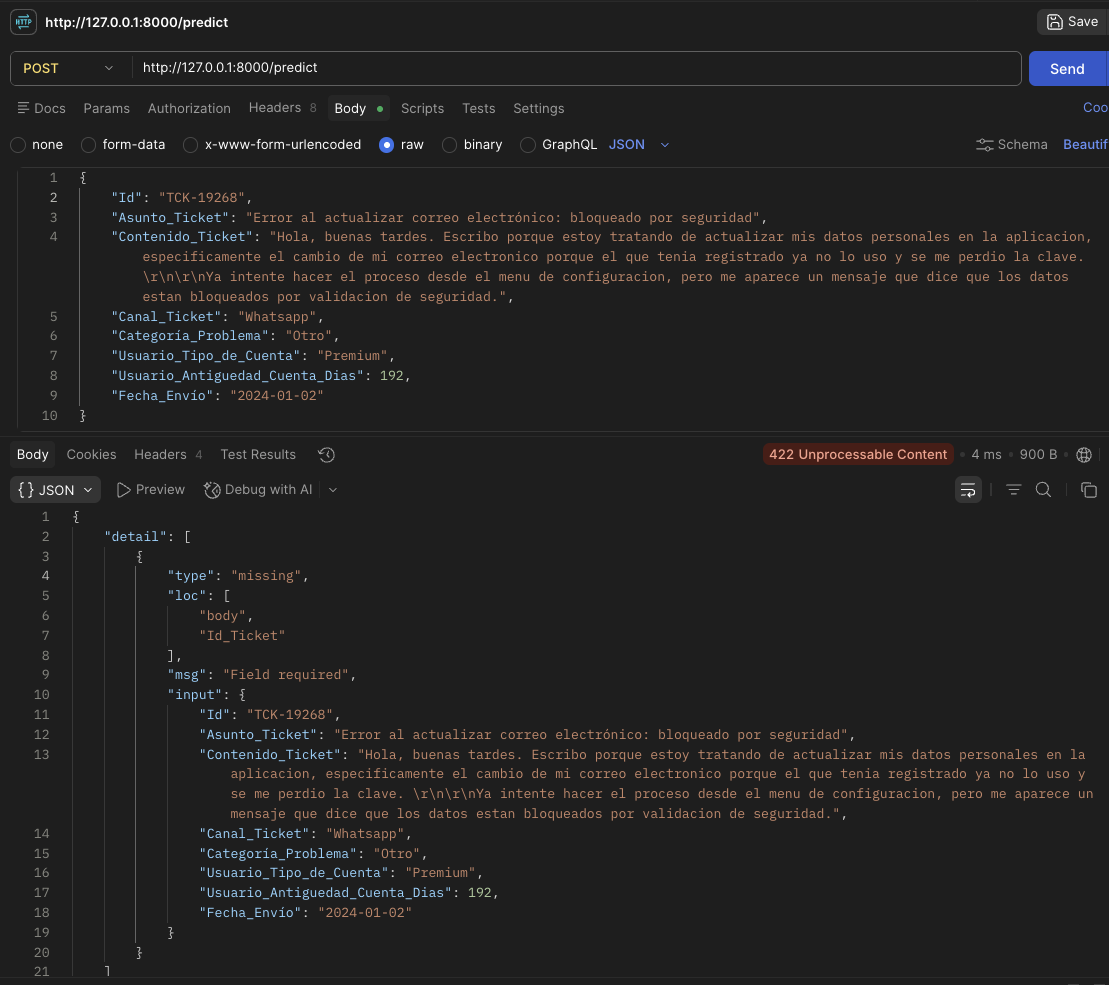

## Sección 3 - Despliegue de Frontend (1.0 pts)

En esta sección debe crear una app de gradio que permita definir en una GUI los input de los tickets para predecir la prioridad del ticket llamando al endpoint definido en la sección anterior.

- Obtener la url de una variable de ambiente llamada `BACKEND_URL`
- Cree el archivo `frontend/app.py` en el que incluirá su app de gradio. 
- Cree el archivo `frontend/services.py` y defina en él la función `enviar_prediccion` que realice la llamada api hacia el endpoint definido en la sección anterior
- Utilice la modalidad `gradio.Blocks` para definir a su app dentro de `frontend/app.py`. Debe:
  - Utilizar colores armoniosos y en lo posible acordes a la estética de **ChaucherApp**
  - Tener secciones separadas para los atributos del ticket y los atributos del usuario
  - En los atributos que tengan una cantidad limitada de opciones, definirlas explícitamentes en la app

- Adjuntar un screenshot de su app con el formulario lleno y la respuesta del modelo llamado.

**Responde aquí**

Se decidio crear el ticket y la fecha mediante service.py para que se realice de manera automática y sin necesidad de que el usuario lo agregue manualmente al no estar conectado a una base de datos.

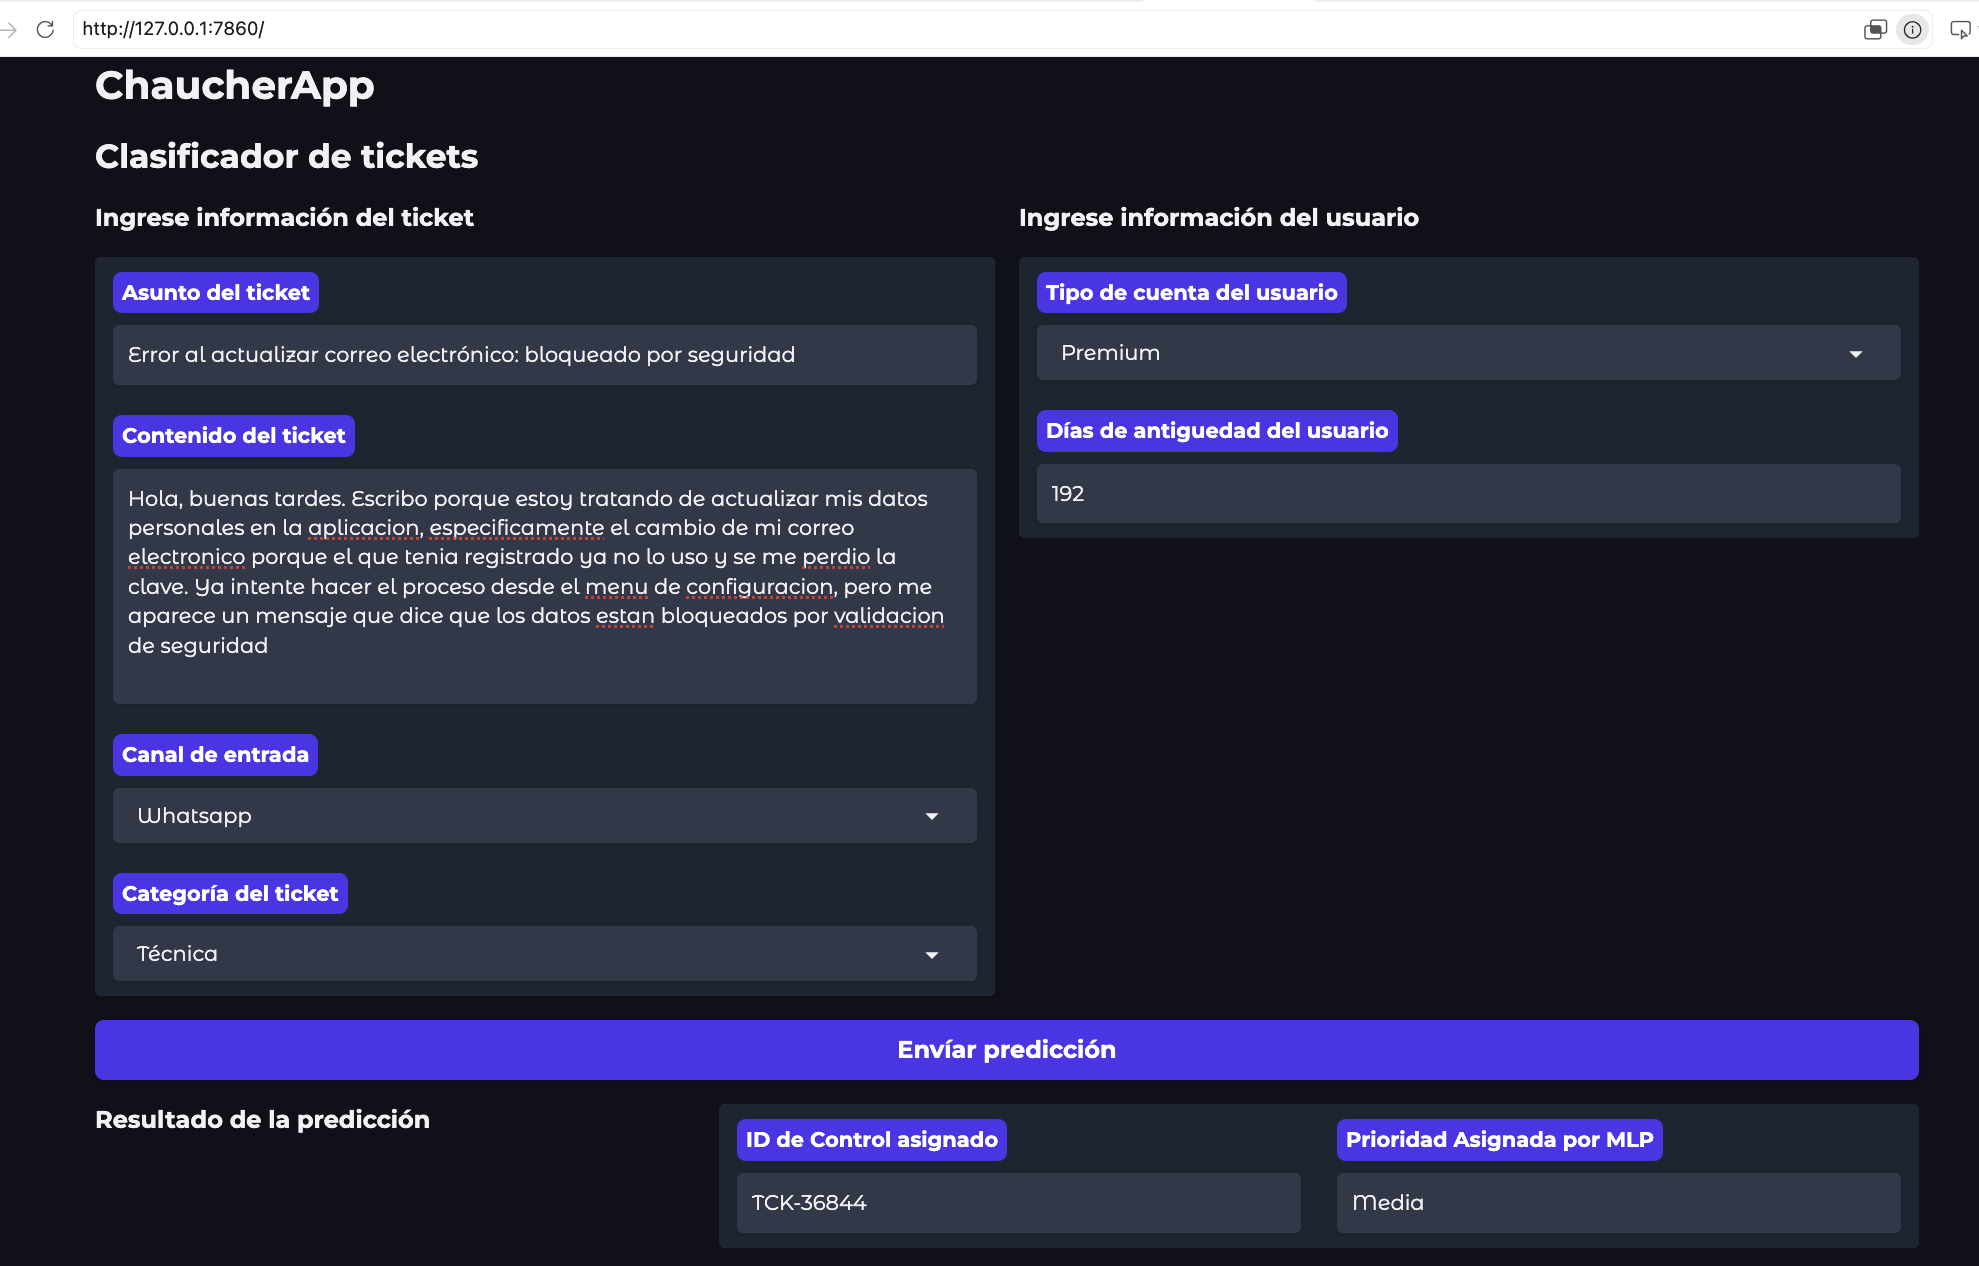

## Sección 4 - Contenerización (2.0 pts)

En esta última sección, usted ya tiene listo el _desarrollo_ de la solución, tanto del modelo predictivo consumido en el **back-end** como de una linda interfaz de usuario definida en el **front-end**. Llegó el momento de **desplegar** la solución en contenedores.

- Genere un archivo `pyproject.toml` para cada servicio (uno para frontend y otro para backend) e incluya las librerías necesarias para su funcionamiento. Luego genere un archivo `uv.lock` con la versión específica de las librerías y dependencias
- No incluya su archivo .env en las imagenes ni en los Dockerfiles ya que podría exponer sus secretos. Las imagenes / Dockerfiles deben ser agnósticas a ambientes, ya que estas variables se definen a nivel contenedor / docker-compose
- Genere un archivo `Dockerfile` para cada servicio. En ellos:
  - Básese en una imagen de python
  - Copie el código y los archivos de uv al workdir dentro del contenedor (`/app`)
  - Ejecute ``uv sync --frozen``
  - Incluya un entrypoint `CMD` al final del Dockerfile con el comando que levanta el servicio
- Construya las imagenes de Docker de cada servicio. En esta etapa puede crear manualmente un contenedor (agregando el mapeo de puertos)en base a cada imagen para probar su funcionamiento correcto. Para cada una puede intentar acceder a su URL. No pruebe más allá de esto.
- Cree un archivo `docker-compose.yaml` afuera de las carpetas de frontend y backend:
  - Defina los servicios `frontend` y `backend`, con nombres de imagenes y contenedores
  - Defina mapeo de volumenes para evitar tener que re-construir la imagen con cada cambio de código
  - Defina variables por contenedor, las cuales las toma de su .env
  - Defina una red interna
- Grabar un video de la pantalla en el que se enciendan los contenedores ya levantados, se abra el frontend, se utilice el frontend obteniendo la prioridad de al menos 6 tickets con características distintas y en los que se observen diferentes prioridades. Muestre también los logs en docker del frontend y del backend. Suba el video a alguna plataforma e incluya el link en la respuesta.

**Responde aquí**

Video: https://drive.google.com/file/d/1Ai3poaFEsGidM4THLXdhnhdx5JxfNgYm/view?usp=sharing

Los tickets utilizados se encuentran en example_tickets.md.